# Notebook for constructing age models for the Portage Lake Volcanics age model

In [1]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Portage Lake Volcanics

- modified from Cannon and Nicholson 2001
- The bottom of the strat is bounded by the Keweenaw fault, we assign a minimum age of 1098 Ma based on the estimated younger side of the known beginning of the normal superchron
- The minimum age bound for the strat bottom is also the date of the Copper City Flow. 
- Greenstone Flows serves as a bound in the middle of the strat
- The top of the strat is bounded by the Nonesuch Formation which has a Re-Os age of 1078 Ma. 

In [10]:
PLV_Name =          ("Copper City Flow base", "Copper City Flow", "Greenstone Flow", "Lake Shore Traps", "base of Nonesuch Shale") # Et cetera
PLV_Age           = [1093.37,                 1093.37,            1091.59,           1085.57,            1078] # Measured ages
PLV_Age_sigma     = [0.53/2,                  0.53/2,             0.27/2,            0.25/2,             24/2] # Measured 1-σ uncertainties
PLV_Height        = [0,                       1000,               3558,              5505,               6055] # Depths below surface should be negative
PLV_Age_Sidedness = [1,                      0,                  0,                 0,                  0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

PLV_Path = "../../data/age_models_output/PLV" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
PLV_section = make_ChronAgeData(PLV_Name, PLV_Age, PLV_Age_sigma, PLV_Height, PLV_Age_Sidedness, PLV_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{5}(("Copper City Flow base", "Copper City Flow", "Greenstone Flow", "Lake Shore Traps", "base of Nonesuch Shale"), [0.0, 1000.0, 3558.0, 5505.0, 6055.0], [0.01, 0.01, 0.01, 0.01, 0.01], [1093.37, 1093.37, 1091.59, 1085.57, 1078.0], [0.265, 0.265, 0.135, 0.125, 12.0], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], "../../data/age_models_output/PLV", 2, "Ma", "m", :cdf)

In [11]:
PLV_age_model_config, PLV_age_model_mdl, PLV_age_model_agedist, PLV_age_model_lldist = run_age_model(PLV_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 848000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 848000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 848000, 1000, 848, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  5960.0, 5970.0, 5980.0, 5990.0, 6000.0, 6010.0, 6020.0, 6030.0, 6040.0, 6050.0], [1095.173825052658, 1095.1630717773496, 1095.146508876714, 1095.1379395194997, 1095.1166650690518, 1095.1025764803085, 1095.089070148913, 1095.0725683152325, 1095.0552310036724, 1095.0509500189821  …  1082.3239372214152, 1082.272268303782, 1082.2208184081655, 1082.1431527287364, 1082.0844107545936, 1082.022130874729, 1081.9715210817733, 1081.9252525524505, 1081.8740417273934, 1081.8319375535443], [1.0967548703489864, 1.0973743295661087, 1.0910941014456474, 1.0940481176641412, 1.0943577468704768, 1.0928838673066497, 1.0950010517427384, 1.0964119057692918, 1.0906567868738162, 1.0886776485726357  …  2.23816297845515, 2.264647091170769, 2.2744812437450728, 2.304300798724238, 2.324951994620868, 2.3359975223080274, 2.3645292587051623, 2.3652231593925923, 2.3799504573039267, 2.37

### posterior summary age model

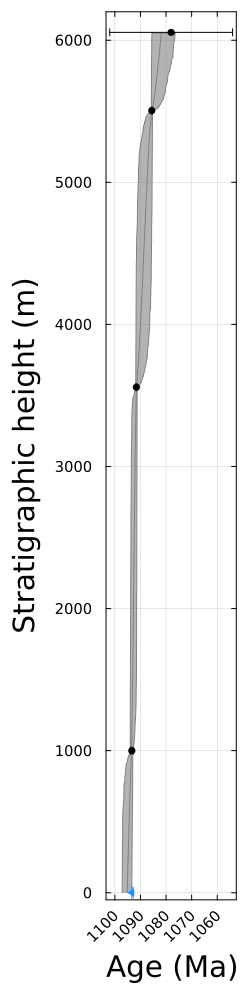

In [12]:
PLV_age_model = plot_age_model(PLV_section, PLV_age_model_mdl, save_figure=false)
plot!(ylim=(-50, 6200), size=(250, 1000), legendfontsize=8)
# add left padding
plot!(left_margin = 12Plots.mm, guidefontsize=20, legend=false)
savefig(PLV_age_model, PLV_section.Path*"_AgeDepthModel.pdf")
display(PLV_age_model)

### example posterior accumulation models

agemin: 1081.8319375535443, agemax: 1095.173825052658, halfw: 1.0, Δt: 0.4
Number of windows: 29
  0.022706 seconds (9.00 k allocations: 14.832 MiB)


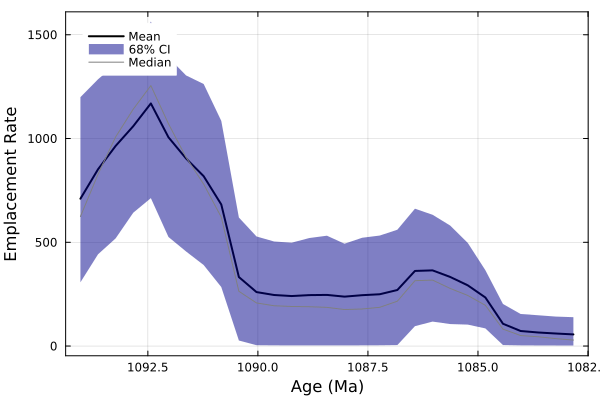

In [13]:
plot_accumulation_model(PLV_section, PLV_age_model_config, PLV_age_model_mdl, PLV_age_model_agedist,  binwidth=2, stepfrac=0.2, save_figure=false)

### example posterior age models

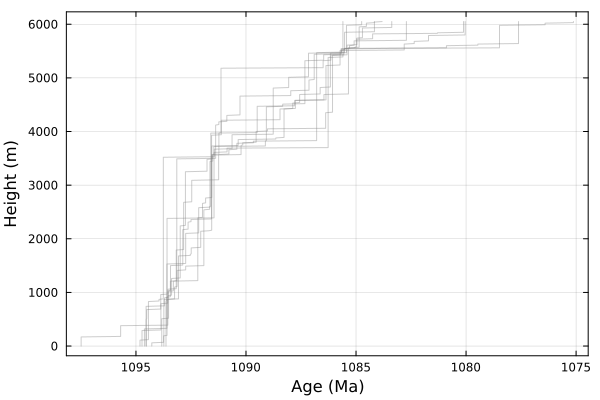

In [14]:
plot_posterior_paths(PLV_section, PLV_age_model_agedist, PLV_age_model_mdl)

## save the age models to a file

In [15]:
PLV_age_model_agedist

606×1000 Matrix{Float64}:
 1095.61  1093.49  1094.2  1094.74  …  1093.38  1096.99  1093.7   1095.6
 1095.61  1093.49  1094.2  1094.74     1093.38  1096.99  1093.7   1094.44
 1095.61  1093.49  1094.2  1094.74     1093.38  1096.99  1093.7   1094.44
 1095.61  1093.49  1094.2  1094.74     1093.38  1096.99  1093.7   1094.44
 1095.61  1093.49  1094.2  1094.74     1093.38  1096.99  1093.7   1094.44
 1095.61  1093.49  1094.2  1094.74  …  1093.38  1096.99  1093.7   1094.44
 1095.61  1093.49  1094.2  1094.74     1093.38  1096.99  1093.7   1094.44
 1095.61  1093.49  1094.2  1094.74     1093.38  1096.99  1093.7   1094.44
 1095.61  1093.49  1094.2  1094.74     1093.38  1096.99  1093.7   1094.44
 1095.61  1093.49  1094.2  1094.74     1093.38  1096.99  1093.7   1094.44
    ⋮                               ⋱                             
 1081.96  1082.56  1085.7  1080.98     1081.32  1080.59  1082.92  1081.86
 1081.96  1082.56  1085.7  1080.98     1081.32  1080.59  1082.92  1081.86
 1081.96  1082.56  1

In [16]:
# use the mdl.height as index, agedist as the data
PLV_age_models_df = DataFrame(hcat(PLV_age_model_mdl.Height, PLV_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(PLV_age_models_df, Dict(:x1 => "height"))
PLV_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1095.61,1093.49,1094.2,1094.74,1095.78,1093.58,1094.9,1096.01,1094.51,1095.03,1093.85,1096.47,1097.13,1095.8,1096.49,1094.03,1097.42,1096.74,1095.22,1095.23,1096.59,1093.86,1094.12,1095.14,1096.2,1093.66,1093.45,1095.5,1096.15,1096.36,1093.43,1095.41,1096.05,1094.54,1095.1,1095.84,1094.54,1094.4,1094.71,1093.94,1095.96,1095.47,1096.78,1094.52,1096.25,1094.39,1096.46,1094.66,1094.66,1094.9,1093.7,1096.29,1095.54,1097.17,1095.98,1093.75,1093.23,1096.73,1094.69,1094.97,1095.47,1095.76,1096.89,1096.7,1096.7,1093.46,1096.32,1095.25,1095.17,1093.25,1097.0,1094.85,1093.61,1095.15,1096.24,1095.6,1095.11,1094.25,1096.92,1093.78,1095.27,1093.97,1095.23,1093.9,1093.87,1096.07,1093.65,1094.16,1093.85,1094.48,1096.77,1095.86,1095.23,1096.16,1094.76,1095.1,1095.26,1096.0,1094.61,⋯
2,10.0,1095.61,1093.49,1094.2,1094.74,1095.78,1093.58,1094.9,1096.01,1094.51,1095.03,1093.85,1096.47,1097.13,1095.8,1096.49,1094.03,1097.42,1096.74,1095.22,1095.23,1096.59,1093.86,1094.12,1095.14,1096.2,1093.66,1093.45,1095.5,1096.15,1096.36,1093.43,1095.41,1096.05,1094.54,1095.1,1095.84,1094.54,1094.4,1094.71,1093.94,1095.96,1095.47,1096.78,1094.52,1096.25,1094.39,1096.46,1094.66,1094.66,1094.9,1093.7,1096.29,1095.54,1097.17,1095.98,1093.75,1093.23,1096.73,1094.69,1094.97,1095.47,1095.76,1096.89,1096.7,1096.7,1093.46,1096.32,1095.25,1095.17,1093.25,1097.0,1094.85,1093.61,1095.15,1096.24,1095.6,1095.11,1094.25,1096.92,1093.78,1095.27,1093.97,1095.23,1093.9,1093.87,1096.07,1093.65,1094.16,1093.85,1094.48,1096.77,1095.86,1095.23,1096.16,1094.76,1095.1,1095.26,1096.0,1094.61,⋯
3,20.0,1095.61,1093.49,1094.2,1094.74,1095.78,1093.58,1094.9,1096.01,1094.51,1095.03,1093.85,1096.47,1097.13,1095.8,1096.49,1094.03,1097.42,1096.74,1095.22,1095.23,1096.59,1093.86,1094.12,1095.14,1096.2,1093.66,1093.45,1095.5,1096.15,1096.36,1093.43,1095.41,1096.05,1094.54,1095.1,1095.84,1094.54,1094.4,1094.71,1093.94,1095.96,1095.47,1096.78,1094.52,1096.25,1094.39,1096.46,1094.66,1094.66,1094.9,1093.7,1096.29,1095.54,1097.17,1095.98,1093.75,1093.23,1096.73,1094.69,1094.97,1094.66,1095.76,1096.89,1096.7,1096.7,1093.46,1096.32,1095.25,1095.17,1093.25,1097.0,1094.85,1093.61,1095.15,1096.24,1095.6,1095.11,1094.25,1096.92,1093.78,1095.27,1093.97,1095.23,1093.9,1093.87,1096.07,1093.65,1094.16,1093.85,1094.48,1096.77,1095.86,1095.23,1096.16,1094.76,1095.1,1095.26,1096.0,1094.61,⋯
4,30.0,1095.61,1093.49,1094.2,1094.74,1095.78,1093.58,1094.9,1096.01,1094.51,1095.03,1093.85,1096.47,1097.13,1095.57,1096.49,1094.03,1097.42,1096.74,1095.22,1095.23,1096.59,1093.86,1094.12,1095.14,1096.2,1093.66,1093.45,1095.5,1096.15,1096.36,1093.43,1095.41,1096.05,1094.54,1095.1,1095.84,1094.54,1094.4,1094.71,1093.94,1095.96,1095.47,1096.78,1094.52,1095.77,1094.39,1096.46,1094.66,1094.66,1094.9,1093.7,1096.29,1095.54,1097.17,1095.98,10

In [17]:
# write the DataFrame to a csv file
CSV.write(PLV_section.Path*"_posterior_ages.csv", PLV_age_models_df)

"../../data/age_models_output/PLV_posterior_ages.csv"